In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_temp = pd.read_csv('HW03.csv')
df_temp = df_temp.set_index("Unnamed: 0")
df = df_temp.copy()
df.columns = df_temp.columns.astype(float)
df = df.rename_axis(index=r"$H_s (m)$", columns=r"$T_s(s)$")
df["Row Sum"] = df.sum(axis=1)
df.loc["Column Sum"] = df.sum()

#make a raw data dataframe
df_raw = df.drop(columns=['Row Sum'])
df_raw = df_raw.drop(index=['Column Sum'])

df

$T_s(s)$,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,Row Sum
$H_s (m)$,,,,,,,,,,,,,,,
0.5,NaN,56.0,48.0,80.0,36.0,108.0,224.0,340.0,432.0,264.0,176.0,72.0,80.0,NaN,1916.0
1.0,NaN,NaN,16.0,164.0,212.0,260.0,328.0,468.0,744.0,612.0,388.0,140.0,48.0,NaN,3380.0
1.5,NaN,NaN,NaN,12.0,176.0,232.0,196.0,244.0,356.0,576.0,192.0,84.0,12.0,NaN,2080.0
2.0,NaN,NaN,NaN,NaN,44.0,92.0,124.0,160.0,236.0,188.0,56.0,20.0,36.0,8.0,964.0
2.5,NaN,NaN,NaN,NaN,4.0,32.0,24.0,44.0,40.0,32.0,4.0,16.0,4.0,NaN,200.0
3.0,NaN,NaN,NaN,NaN,NaN,20.0,4.0,16.0,28.0,20.0,24.0,16.0,8.0,4.0,140.0
3.5,NaN,NaN,NaN,NaN,NaN,6.0,9.0,3.0,9.0,6.0,12.0,6.0,6.0,NaN,57.0
4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,4.0,6.0,NaN,2.0,NaN,2.0,16.0
4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,2.0,2.0,NaN,NaN,7.0


# 1)

In [3]:
#Number of measurements and total occurances
num_meas = df['Row Sum'].iloc[-1]
total_occur = num_meas + 1559

#number of occurances below 2.5 + half of the ones in the 2.5 bin
under_25 = df["Row Sum"].loc[np.arange(0.5, 2.5, .5)].sum() + 0.5 * df['Row Sum'].loc[2.5]
#probability of being over 2.5 = number of occurances over 2.5 / total occurances
over_25 = ((num_meas - under_25) / total_occur) * 100
under_25, over_25

(np.float64(8440.0), np.float64(3.2791642484039465))

# 2)

In [4]:
#df_raw

In [5]:
#Getting total number of waves and total number of waves per year
#Cover the six hour measurement period into seconds
six_hr = 6 * 60 * 60

#Divide six hours of time by the T_P for each value, then multiply by the number of occurances
df_waves = df_raw * (six_hr / df_raw.columns.astype(float))

#Get number of hours from number of measurements, convert to number of years
total_time_hr = total_occur * 6
hrperyear = 365 * 24
num_yr = total_time_hr/hrperyear

#divide total waves by number of years to get waves per year
df_waves_peryr = df_waves / num_yr

#number of waves per year
N_waves_peryr = df_waves_peryr.sum().sum()
N_waves_peryr, num_yr

(np.float64(3426881.1229397417), np.float64(7.080821917808219))

In [6]:
#H_rms helper eq
def get_Hrms(Hs):
    return (Hs / np.sqrt(2))
#generate some wave height values
H = np.linspace(0, 35, 1000)

#Get Hs values
Hs = df_raw.index.astype(float)

#get Hrms for each Hs bin
Hrms_list = get_Hrms(Hs).to_numpy()

#create empty dataframe for output arrays
df_prob = pd.DataFrame(index=np.arange(len(Hrms_list)), columns=['Hs', 'P'], dtype=object)

#loop through each Hrms value and get probability density
for i in range(len(Hrms_list)):
    Hrms = Hrms_list[i]
    #P(H) equation
    p_dist = (2*H / (Hrms**2)) * np.exp(-((H/Hrms)**2)) 
    
    #add arrays to dataframe for plotting
    df_prob.at[i, 'Hs'] = Hs[i]
    df_prob.at[i, 'P'] = p_dist


#df_prob

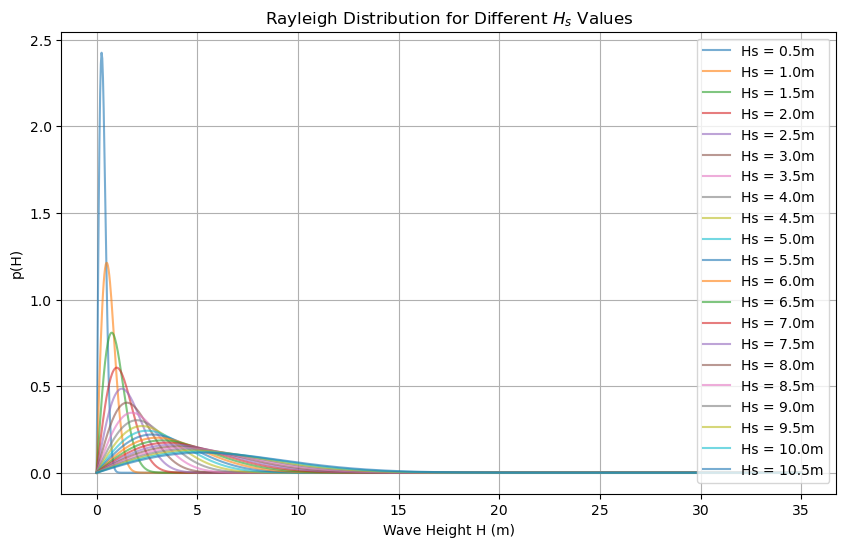

In [63]:
#plotting the Rayleigh Dist. for each Hs value
plt.figure(figsize=(10,6))

#for loop that plots each line
for i in range(len(df_prob)):
    Hs = df_prob.at[i, 'Hs']
    P = df_prob.at[i, 'P']
    plt.plot(H, P, alpha=0.6, label=f'Hs = {Hs}m')

plt.xlabel("Wave Height H (m)")
plt.ylabel("p(H)")
plt.title(r"Rayleigh Distribution for Different $H_s$ Values")
plt.legend()
plt.grid(True)
plt.savefig('Part 2 Rayleigh Dist')
plt.show()

In [64]:
#Build a matrix of the PDFs for each HS
P_matrix = np.zeros((len(Hrms_vals), len(H)))
for i, Hrms in enumerate(Hrms_vals):
    P_matrix[i, :] = (2*H / Hrms**2) * np.exp(-(H/Hrms)**2)

#Get the number of waves per Hs per year
Hs_waves_peryr = df_waves_peryr.sum(axis=1).to_numpy()
#Get the weight fractions per Hs value
w_frac = Hs_waves_peryr / N_waves_peryr                     
#multiply each PDF by the weight fraction
P_weighted = P_matrix * w_frac[:, None]
#Get the weighted wave probability
P_weighted_waves = P_weighted * Hs_waves_peryr[:, None]

#Sum the PDFs to get a massive
combined = P_weighted_waves.sum(axis=0) 
#Normalize it into a pdf for an entire year's population
combined_pdf = combined / combined.sum()
# Convert to expected number of waves
wave_est = combined_pdf * N_waves_peryr

N_waves_peryr

np.float64(3426881.122939742)

In [266]:
# make bins
bin_width = 0.25
bins = np.arange(0, 10 + bin_width, bin_width)

#Use numpy to organize values
bin_indices = np.digitize(H, bins) - 1 
#Make empty array for histogram count
hist_rebinned = np.zeros(len(bins))
#Do the bin counts
for i, count in enumerate(wave_est):
    b = bin_indices[i]
    if 0 <= b < len(hist_rebinned):
        hist_rebinned[b] += count

#Organize counts using Dataframe for plotting
df_hist = pd.DataFrame({
    "H_bin_lower": bins,
    "H_bin_upper": bins + bin_width,
    "waves_per_year": hist_rebinned
})

#df_hist

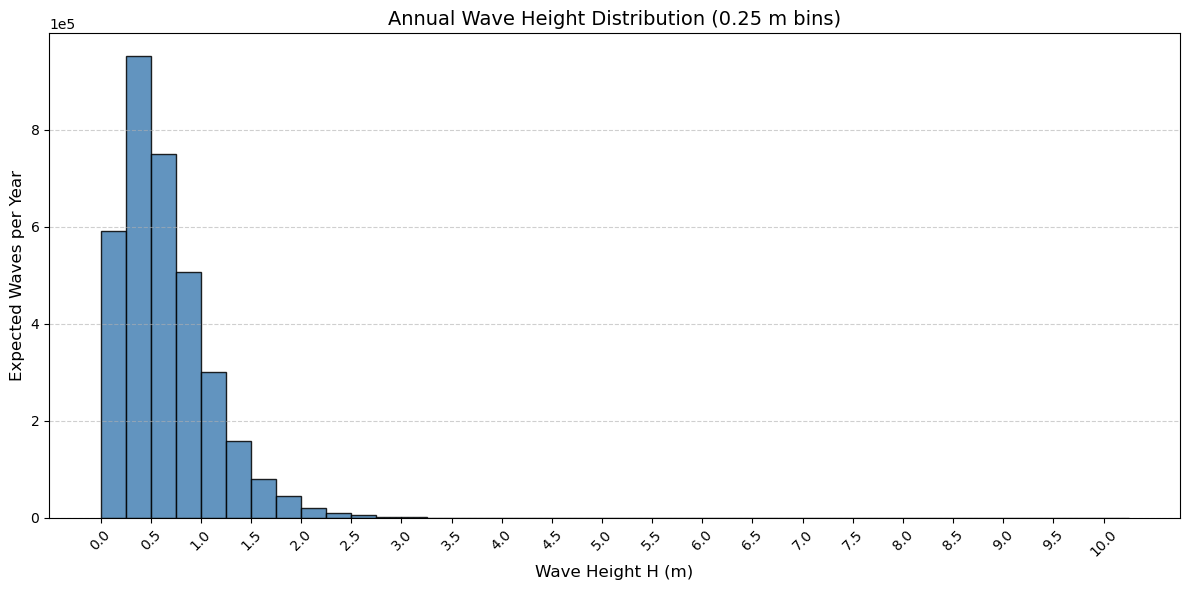

In [71]:
plt.figure(figsize=(12,6))
plt.bar(
    df_hist["H_bin_lower"],
    df_hist["waves_per_year"],
    width=bin_width,
    align="edge",
    edgecolor="black",
    color="steelblue",
    alpha=0.85
)

plt.xlabel("Wave Height H (m)", fontsize=12)
plt.ylabel("Expected Waves per Year", fontsize=12)
plt.title("Annual Wave Height Distribution (0.25 m bins)", fontsize=14)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.grid(axis="y", linestyle="--", alpha=0.6)
tick_positions = df_hist["H_bin_lower"][::2]
tick_labels = [f"{x:.1f}" for x in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45)
plt.tight_layout()
plt.savefig('Part 2 Histogram.jpg')
plt.show()


# 3)

In [135]:
#Wave heights for extreme events
Hs_vals = [5.5,5.5,5.5,5.5,6,6,6,6.5,6.5,7,7.5,8,9,10.5]
Tp_vals = [10, 11, 11, 13, 11,12,14,11,13,12,13,12,13,13]
N = len(Hs_vals)
P_vals = (np.arange(1, N+1)) / (N + 1)

k=0.73

#Calculate x values for log-normal plot
X = (-np.log(1 - P_vals))**(1/k)

In [121]:
#linear regression
slope, intercept = np.polyfit(X, Hs_vals, 1)
Hs_fit = slope * X + intercept

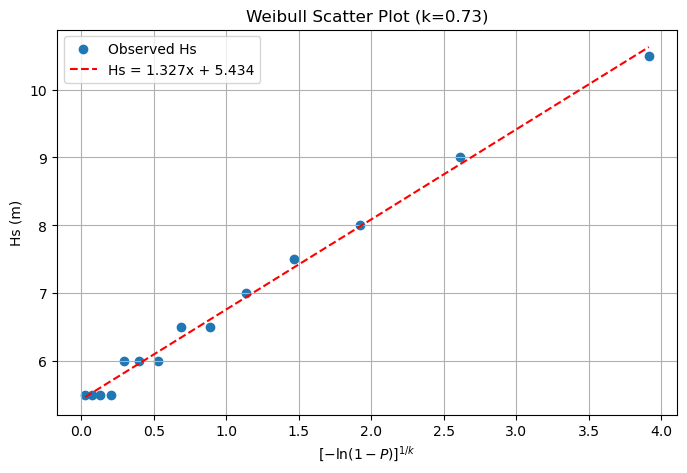

In [125]:
#plot
plt.figure(figsize=(8,5))
plt.scatter(X, Hs_vals, label='Observed Hs')
plt.plot(X, Hs_fit, color='r', linestyle='--', label=f'Hs = {slope:.3f}x + {intercept:.3f}')
plt.xlabel(r'$[-\ln(1-P)]^{1/k}$')
plt.ylabel('Hs (m)')
plt.title(f'Weibull Scatter Plot (k={k})')
plt.legend()
plt.grid(True)
plt.savefig('Part 3 Weibull.jpg')
plt.show()

In [137]:
#calculating 25 year significant wave height
RI = num_yr/len(Hs_vals)
Q_25yr = RI / 25
Hs_25yr = slope * (-np.log(Q_25yr))**(1/k) + intercept
#corresponding period
Tp_mean = np.mean(Tp_vals)
Hs_25yr, Tp_mean

(np.float64(13.994740614624085), np.float64(12.071428571428571))

In [138]:
# Example values
n = len(Hs_vals)
T_R = 25
L = 5

# Calculate probability
E = 1 - (1 - 1/(n * T_R))**(n * L)
E

0.1815035829769791

# 4)

In [142]:
#Calculate Bretschneider specturm
def bret_spec(f, H_s, f_p):
    S_f = (5 * H_s**2 / (16 * f_p)) * (f / f_p)**(-5) * \
          np.exp(-5/4 * (f / f_p)**(-4))
    return S_f


f = np.linspace(0.01, 1, 1000)  # avoid f=0
f_p = 1/Tp_mean

bret_vals = bret_spec(f, Hs_25yr, f_p)

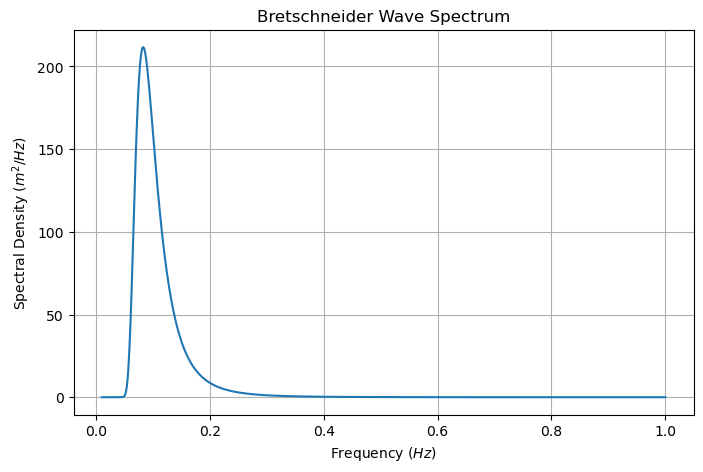

In [148]:
plt.figure(figsize=(8,5))
plt.plot(f, bret_vals)
plt.xlabel(f'Frequency $(Hz)$')
plt.ylabel(r'Spectral Density $(m^2/Hz)$')
plt.title('Bretschneider Wave Spectrum')
plt.grid(True)
plt.show()

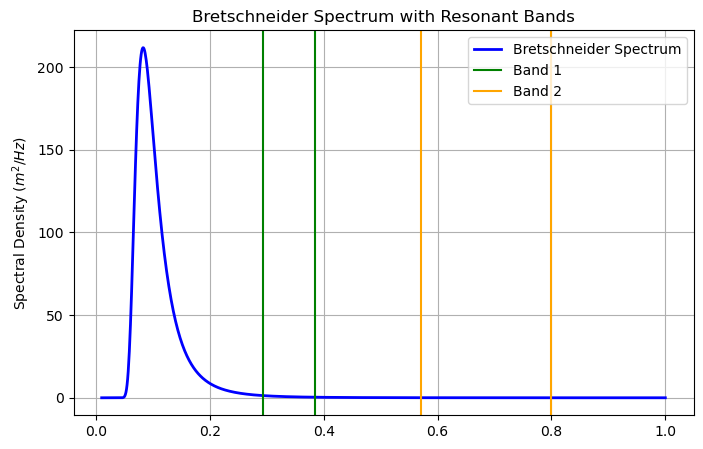

In [163]:
#Get Band intervals
band_pds = np.array([(2.6, 3.4), (1.25, 1.75)])
intervals = np.array([(1/pd[1], 1/pd[0]) for pd in band_pds])

#Plot
plt.figure(figsize=(8,5))
plt.plot(f, bret_vals, color='blue', lw=2, label='Bretschneider Spectrum')
plt.axvline(1/2.6, color='green', label=f'Band 1')
plt.axvline(1/3.4, color='green')
plt.axvline(1/1.25, color='orange', label=f'Band 2')
plt.axvline(1/1.75, color='orange')
plt.ylabel(r'Spectral Density $(m^2/Hz)$')
plt.title('Bretschneider Wave Spectrum')
plt.title('Bretschneider Spectrum with Resonant Bands')
plt.legend()
plt.grid(True)
plt.savefig('Part4: Bret.jpg')
plt.show()

In [161]:
band_areas = []

#integrate under curve over bands
for f_start, f_end in intervals:
    mask = (f >= f_start) & (f <= f_end)
    area = np.trapezoid(bret_vals[mask], f[mask])
    band_areas.append(area)

#Get total area
total_area = np.trapezoid(bret_vals, f)

#normalize to get percentages
band1_per = band_areas[0] / total_area
band2_per = band_areas[1] / total_area

band1_per, band2_per, band1_per + band2_per

(np.float64(0.005117738005990865),
 np.float64(0.00040636172897088517),
 np.float64(0.0055240997349617505))

# 5)

In [260]:
num_bins = 30000

#dicretize spectrum
f_bins = np.linspace(0.01, 1.0, num_bins)
delta_f = f_bins[1] - f_bins[0]

#Get S values
S_f = bret_spec(f_bins, Hs_25yr, f_p)
#Get ai values
a_i = np.sqrt(2 * S_f * delta_f)
#Get alpha values
alpha_i = np.random.uniform(0, 2*np.pi, num_bins)  # Make sure length matches f_bins

#make time vector
T_total = 20 * 60
t = np.linspace(0, T_total, num_bins)

eta_t = np.sum(a_i[:,None] * np.cos(2*np.pi*f_bins[:,None]*t[None,:] + alpha_i[:,None]), axis=0)


In [261]:
#Find crossings and interpolate
sign_changes = np.where(np.diff(np.sign(eta_t)))[0]
t_zero = t[sign_changes] - eta_t[sign_changes] * (t[sign_changes+1] - t[sign_changes]) / \
         (eta_t[sign_changes+1] - eta_t[sign_changes])
eta_zero = np.zeros_like(t_zero)

#Select only upward crossings (negative to positive)
upward_mask = eta_t[sign_changes] < 0
t_upward = t_zero[upward_mask]
eta_upward = eta_zero[upward_mask]
#Count upward zero crossings
num_upward = len(t_upward)

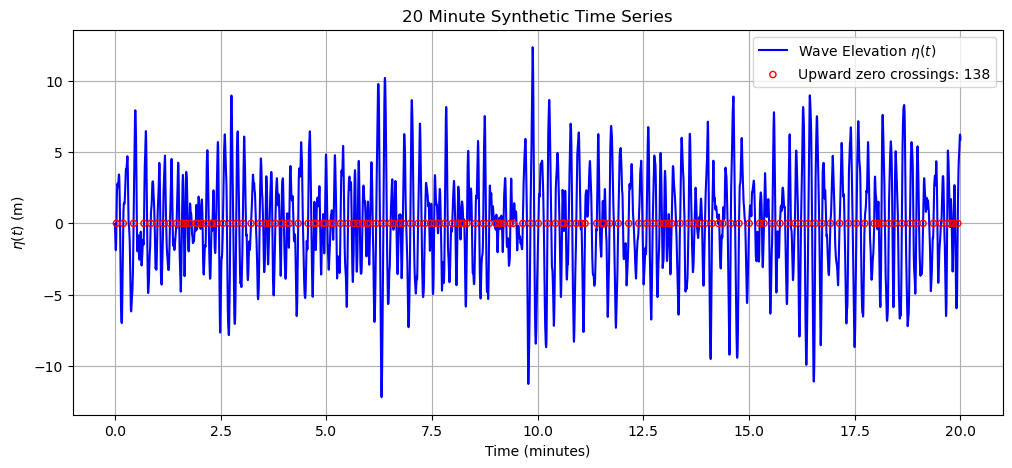

In [262]:
plt.figure(figsize=(12,5))
plt.plot(t/60, eta_t, color='blue', lw=1.5, label='Wave Elevation $\eta(t)$')
plt.scatter(
    t_upward/60, eta_upward,
    marker='o',
    facecolors='none',
    edgecolors='red',
    s=20,
    zorder=5,
    label=f'Upward zero crossings: {num_upward}')
plt.xlabel('Time (minutes)')
plt.ylabel(r'$\eta(t)$ (m)')
plt.title('20 Minute Synthetic Time Series')
plt.legend()
plt.grid(True)
plt.savefig('Part 5 20 min.jpg')
plt.show()

In [232]:
T_total_10 = 10 * 60
t_10 = np.arange(0, T_total_10, dt)

In [233]:
#repeat for 10 minutes
T_total_10 = 10 * 60
t_10 = np.arange(0, T_total_10, dt)

sign_changes_10 = np.where(np.diff(np.sign(eta_t_10)))[0]
t_zero_10 = t_10[sign_changes_10] - eta_t_10[sign_changes_10] * (t_10[sign_changes_10 + 1] - t_10[sign_changes_10]) / \
            (eta_t_10[sign_changes_10 + 1] - eta_t_10[sign_changes_10])
eta_zero_10 = np.zeros_like(t_zero_10)
num_zeros_10 = len(t_zero_10)


upward_mask = eta_t_10[sign_changes_10] < 0  # if eta before crossing is negative, it's upward
t_upward = t_zero_10[upward_mask]
eta_upward = eta_zero_10[upward_mask]
num_upward = len(t_upward)

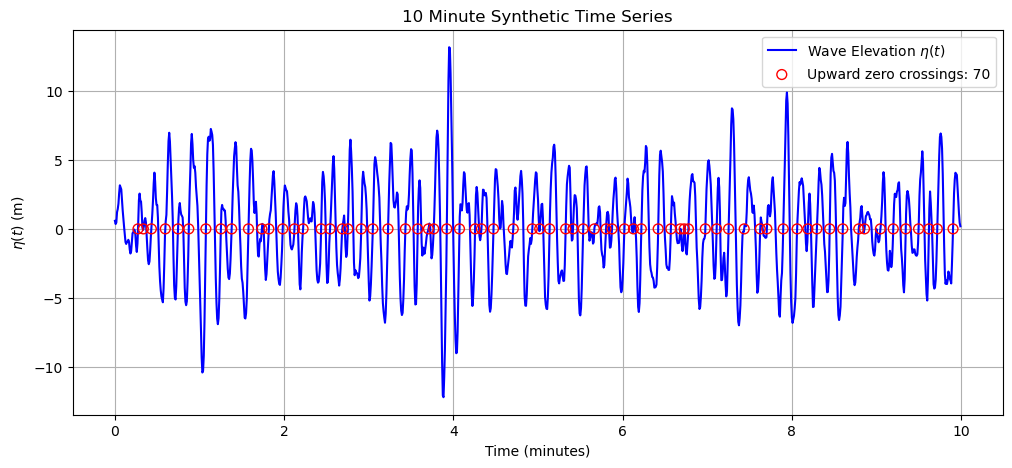

In [234]:
plt.figure(figsize=(12,5))
plt.plot(t_10/60, eta_t_10, color='blue', lw=1.5, label='Wave Elevation $\eta(t)$')
plt.scatter(
    t_upward/60, eta_upward,
    marker='o',
    facecolors='none',
    edgecolors='red',
    s=50,
    zorder=5,
    label=f'Upward zero crossings: {num_upward}')
plt.xlabel('Time (minutes)')
plt.ylabel(r'$\eta(t)$ (m)')
plt.title('10 Minute Synthetic Time Series')
plt.legend()
plt.grid(True)
plt.savefig('Part 5 10 min.jpg')
plt.show()

In [263]:
#Get the significant wave height of the simulated series
def Hs_simulated(t, eta):
    #Get crossings using same method
    sign_change_idx = np.where(np.diff(np.sign(eta)) != 0)[0]
    up_mask = (eta[sign_change_idx] < 0) & (eta[sign_change_idx+1] > 0)
    idx = sign_change_idx[up_mask]
    # Interpolate times
    t0 = t[idx] - eta[idx] * (t[idx+1] - t[idx]) / (eta[idx+1] - eta[idx])
    
    #Get wave heights
    wave_heights = []
    for i in range(len(t0)-1):
        #Change in time
        m = (t >= t0[i]) & (t < t0[i+1])
        #Get the height using max-min
        if np.any(m):
            eta_seg = eta[m]
            H = eta_seg.max() - eta_seg.min()
            wave_heights.append(H)
    #Get wave heights in array and get total number
    wave_heights = np.array(wave_heights)
    N = len(wave_heights)
    print(N)
    
    #Average the highest 1/3
    Hs = np.mean(np.sort(wave_heights)[-max(1, N//3):])
    return Hs


#Run function for the two series
Hs_20 = Hs_simulated(t, eta_t)
Hs_10 = Hs_simulated(t_10, eta_t_10)

round(Hs_10,3), round(Hs_20,3)

137
69


(np.float64(12.541), np.float64(13.845))

In [264]:
#calculate relative error:
err_10 = (Hs_25yr - Hs_10) / Hs_25yr
err_20 = (Hs_25yr - Hs_20) / Hs_25yr

err_10*100, err_20*100

(np.float64(10.388920543907453), np.float64(1.0715010512294831))

# 6)

In [270]:
Hs_25yr, Tp_mean

(np.float64(13.994740614624085), np.float64(12.071428571428571))

In [301]:
# 12 hr storm
Tstorm = 12*60*60
Nstorm = Tstorm / Tp_25 # waves per storm

#H_max
H_max = Hs_25 * np.sqrt(0.5 * np.log(Nstorm))
#Storm H_rms
Hrms_25 = Hs_25 / np.sqrt(2)

In [ ]:
#Make input values
dH = 0.01
H_storm = np.arange(0, 30 + dH, dH)
#get PDF
p_H_25 = (2 * H_storm / Hrms_25**2) * np.exp(-(H_storm / Hrms_25)**2)
#Scale by number of waves
pH_NumStormWaves = p_H_25 * Nstorm

In [307]:
#Critical wave height from ACES
H_slam = 19.79 
#Find region abovd H_slam
idxSlam = H_storm >= H_slam
#Integrate
slamWaves = np.trapezoid(pH_NumStormWaves[idxSlam], H_storm[idxSlam])

slamWaves

np.float64(65.22233903408423)

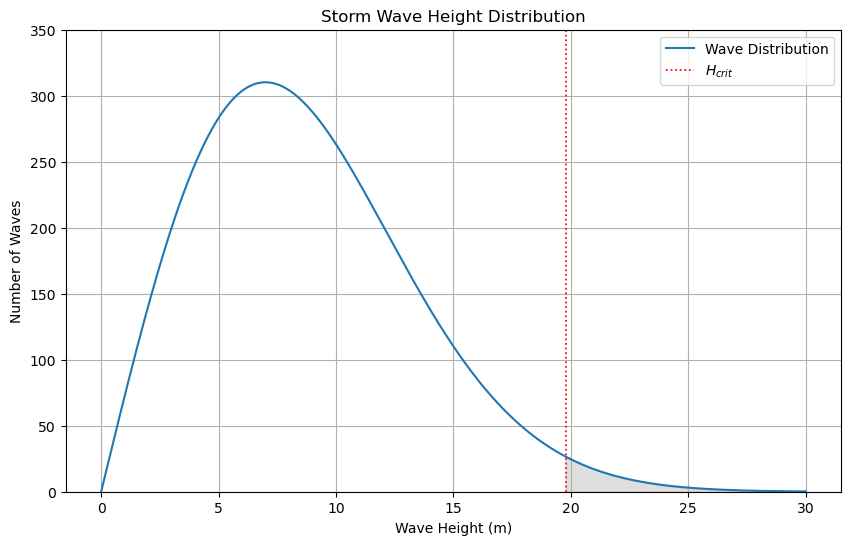

In [308]:
plt.figure(figsize=(10,6))
plt.plot(H_storm, pH_NumStormWaves, linewidth=1.5, label='Wave Distribution')
plt.ylim([0, 350])
plt.axvline(H_slam, color='r', linestyle=':', linewidth=1.25, label=r'$H_{crit}$')
#plt.axvline(H_max, color=(0,0.5,0), linestyle=':', linewidth=1.25, label='Maximum Wave Height $H_{max}$')
plt.fill_between(
    H_storm[idxSlam],
    pH_NumStormWaves[idxSlam],
    color=[0.5,0.5,0.5],
    alpha=0.25)
plt.title('Storm Wave Height Distribution')
plt.xlabel('Wave Height (m)')
plt.ylabel('Number of Waves')
plt.legend()
plt.grid(True)
plt.savefig('Part 6 Distribution.jpg')
plt.show()

# 7)

In [380]:
depth = 83.5 #water depth
L = 242.338
H_max / depth, Tp_mean

(np.float64(0.3390104909457457), np.float64(12.071428571428571))

In [346]:
H_max, depth

(np.float64(28.307375993969764), 83.5)

In [381]:
#ACES Data
x = np.array([
    -121, -120, -110, -105, -100, -95, -90, -85, -80, -75,
    -70, -65, -60, -55, -50, -45, -40, -35, -30, -25,
    -20, -15, -10, -5, 0, 5, 10, 15, 20, 25,
    30, 35, 40, 45, 50, 55, 60, 65, 70, 75,
    80, 85, 90, 95, 100, 105, 110, 120, 121
], dtype=float)

height = np.array([
    -10.5, -10.5, -10.24, -9.957, -9.565, -9.07, -8.464, -7.75, -6.923, -5.983,
    -4.927, -3.753, -2.461, -1.044, 0.4924, 2.152, 3.931, 5.823, 7.82, 9.892,
    12, 14.86, 15.91, 17.27, 17.81, 17.27, 15.91, 14.86, 12, 9.892,
    7.82, 5.823, 3.931, 2.152, 0.4924, -1.044, -2.461, -3.753, -4.927, -5.983,
    -6.923, -7.75, -8.464, -9.07, -9.565, -9.957, -10.24, -10.5, -10.5
], dtype=float)

In [382]:
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad


In [409]:
# s controls smoothing strength (lower = more wiggly, higher = smoother)
spline = UnivariateSpline(x, height, s=.5)

# Generate smooth curve
xs = np.linspace(x.min(), x.max(), 3000)
ys = spline(xs)

In [414]:
#dock water line
y_line = 11.5

#make mask for integration
mask = (xs >= -25) & (xs <= 25)
xs_zoom = xs[mask]
ys_zoom = ys[mask]
above_mask = ys_zoom > y_line

#Integrate over platform
xs_above = xs_zoom[above_mask]
ys_above = ys_zoom[above_mask]

#get delta_y
vertical_dist_above = ys_above - y_line
area_above = np.trapezoid(vertical_dist_above, xs_above)

area_above

np.float64(171.95273987049313)

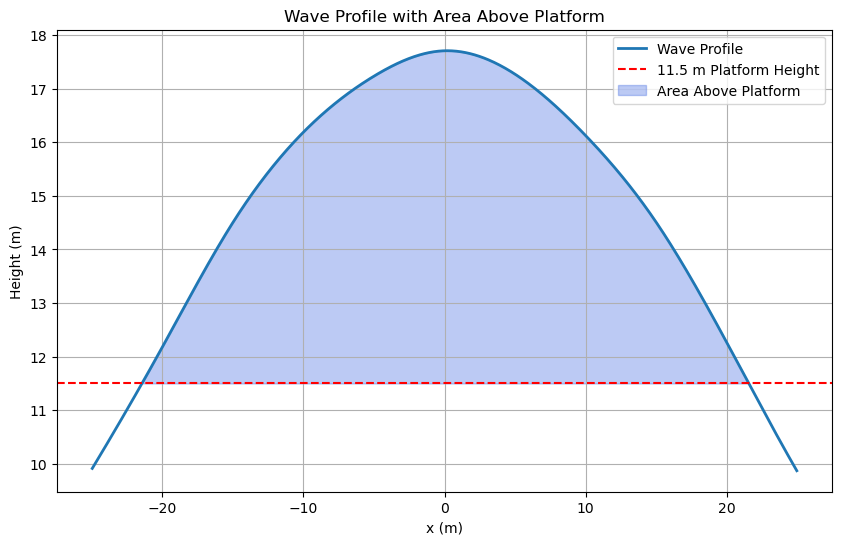

In [425]:
plt.figure(figsize=(10, 6))
plt.plot(xs_zoom, ys_zoom, '-', label='Wave Profile', linewidth=2)
plt.axhline(y_line, color='red', linestyle='--', label='11.5 m Platform Height')

#Shade integrated area
plt.fill_between(xs_zoom, ys_zoom, y_line,
                 where=(ys_zoom > y_line),
                 color='royalblue', alpha=0.35,
                 label='Area Above Platform')
plt.xlabel("x (m)")
plt.ylabel("Height (m)")
plt.title("Wave Profile with Area Above Platform")
plt.legend()
plt.grid(True)
plt.savefig("Part 7 Wave Form.jpg")
plt.show()

In [432]:
#density of seawater
rho = 1025 
g = 9.81

#Force per width
W_perwidth = area_above * rho * g
W_perwidth/1000

np.float64(1729.0277875827762)

In [434]:
coef = 2 #from Lai Lee
hypot = np.sqrt(30**2 + 40**2)

#longest possible length. 
load_max = W_perwidth * coef * hypot

load_max/1000, hypot

(np.float64(172902.77875827762), np.float64(50.0))